Exploratory Data Analysis

In [1]:
# dataset : 'https://drive.google.com/file/d/1Jm4rFVh-sH9yDkx3v_BL2EruHdnmenGk/view?usp=sharing'

In [2]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Loading data

df = pd.read_csv('customer_churn_.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df['TotalCharges'] = df['TotalCharges'].replace(' ',np.nan)
df['TotalCharges'] = df['TotalCharges'].astype('float')

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [8]:
df.isnull().sum().sum()

np.int64(11)

In [9]:
df.dropna(inplace=True)

In [10]:
df.duplicated().sum()

np.int64(0)

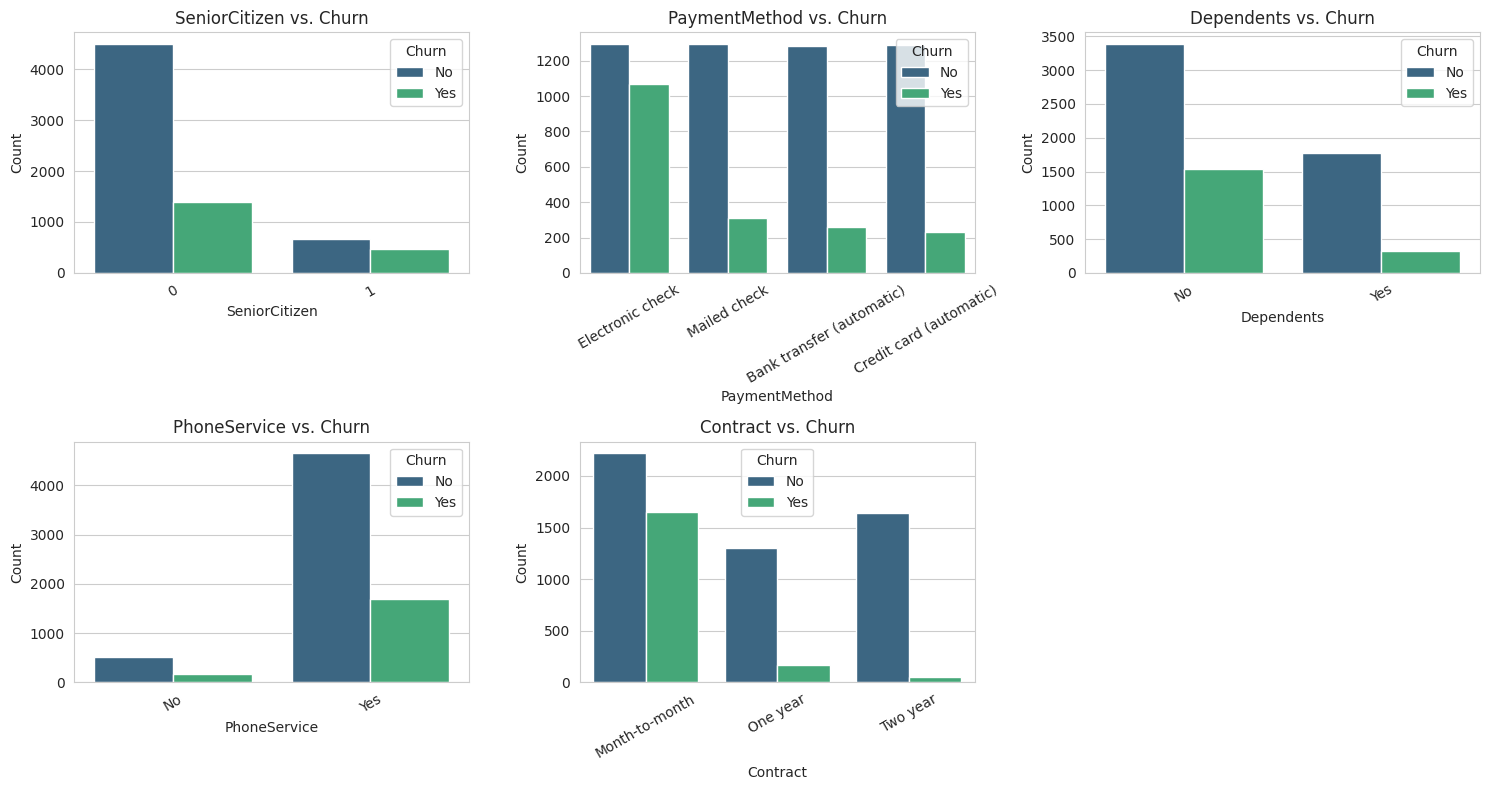

In [11]:
sns.set_style("whitegrid")

features_to_plot = ['SeniorCitizen', 'PaymentMethod', 'Dependents', 'PhoneService', 'Contract']

num_features = len(features_to_plot)
num_cols = 3
num_rows = (num_features + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 4))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.countplot(data=df, x=col, hue='Churn', palette='viridis', ax=axes[i])
    axes[i].set_title(f'{col} vs. Churn')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)

for j in range(num_features, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Churn is highest among month-to-month contracts, electronic check users, customers without dependents, and senior citizens, highlighting these groups as risk segments.

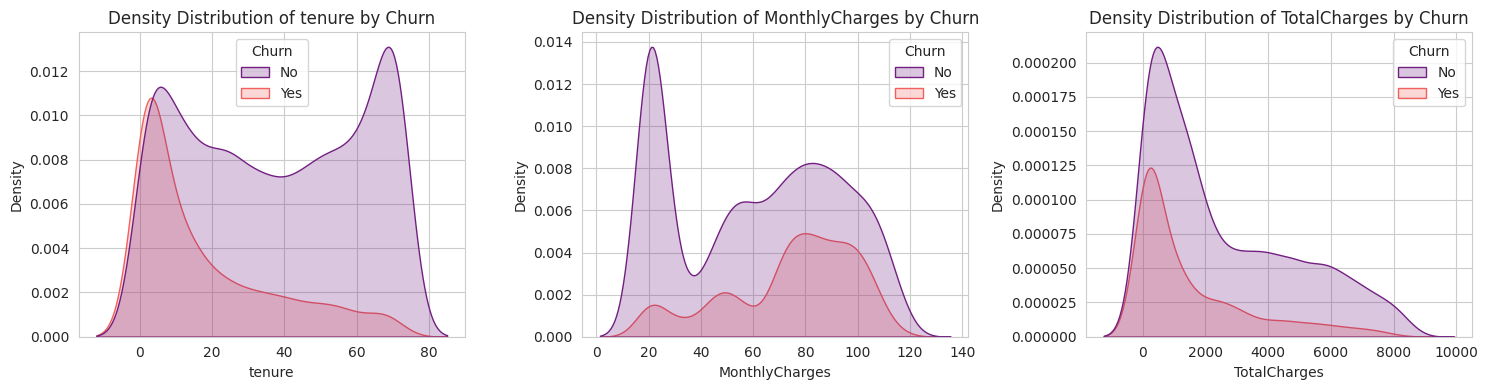

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

num_features = len(numerical_features)
num_cols = 3
num_rows = (num_features + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, palette='magma', ax=axes[i])
    axes[i].set_title(f'Density Distribution of {col} by Churn')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')

for j in range(num_features, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Customers who churn typically have shorter tenure and lower total charges but relatively higher monthly charges.

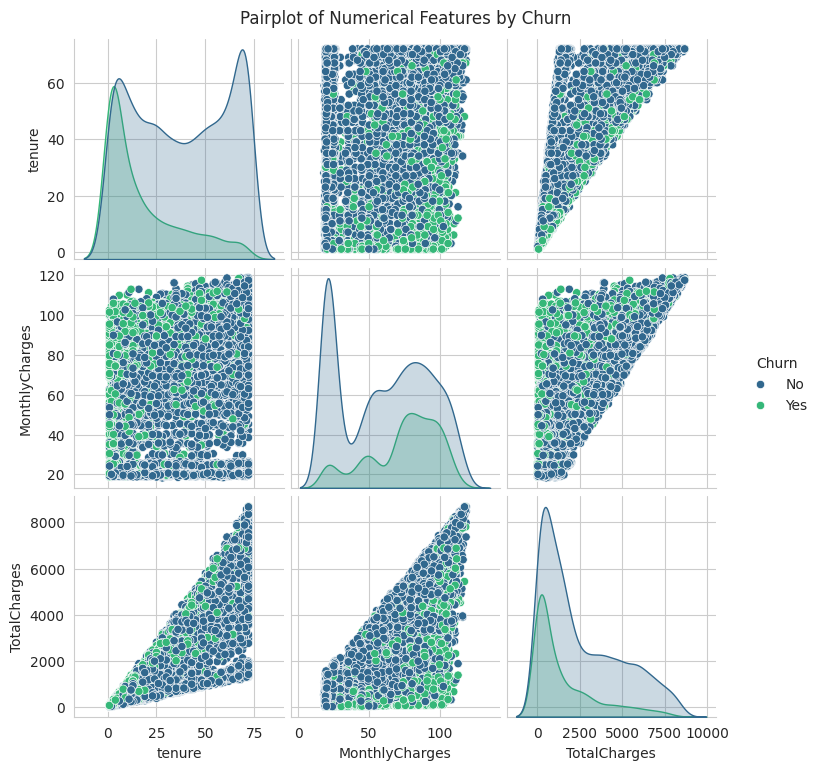

In [13]:
sns.set_style("whitegrid")

numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

sns.pairplot(df[numerical_features + ['Churn']], hue='Churn', palette='viridis')
plt.suptitle('Pairplot of Numerical Features by Churn', y=1.02) # Adjust suptitle position
plt.show()


Churned customers cluster at low tenure and lower total charges, confirming that early-stage customers are more likely to leave.

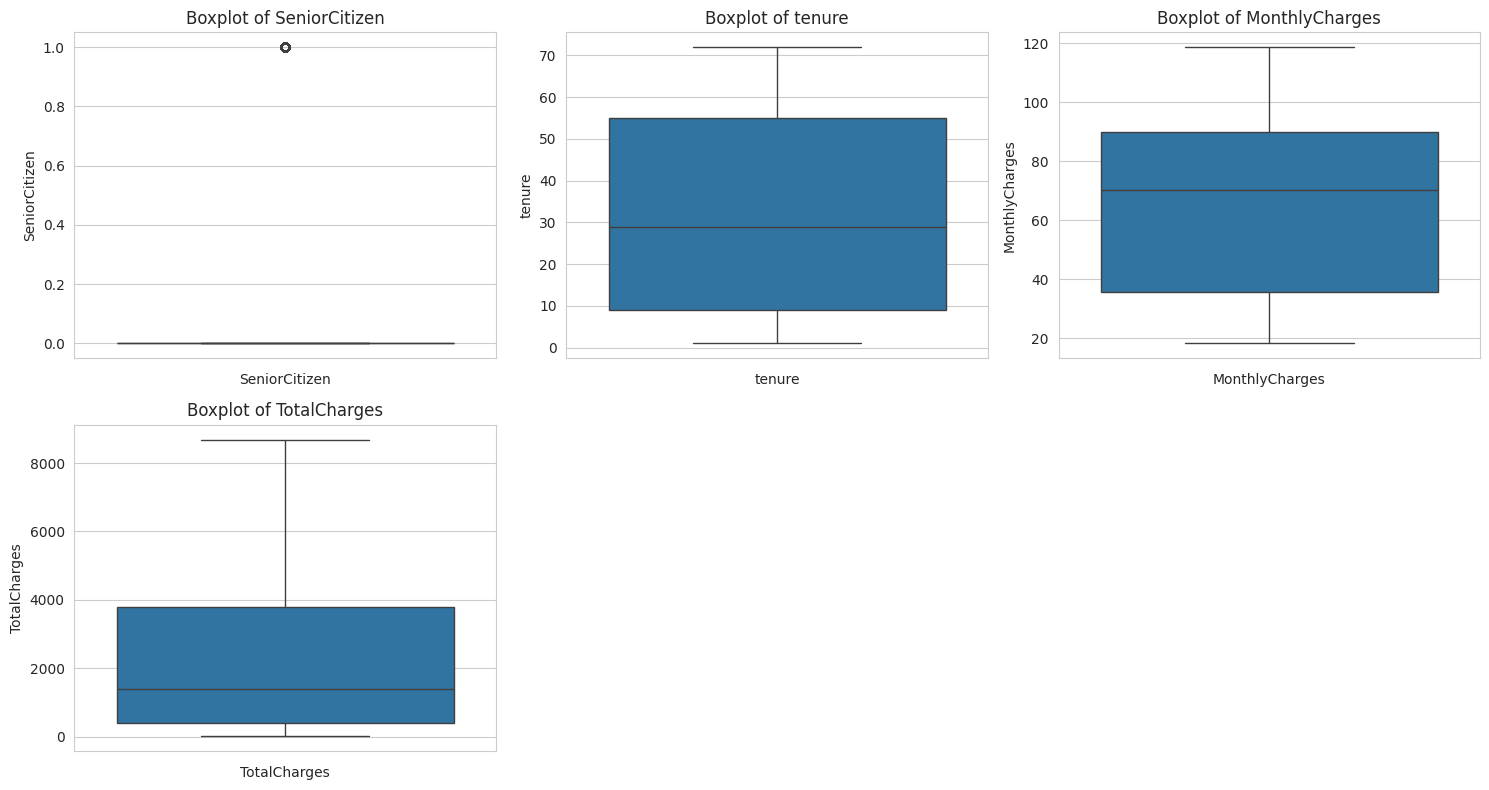

In [14]:
# Checking for outliers for selected numerical features

numerical_cols = [col for col in df.columns if df[col].dtype != 'object']

num_numerical_cols = len(numerical_cols)
num_cols = 3
num_rows = (num_numerical_cols + num_cols - 1) // num_cols

plt.figure(figsize=(num_cols * 5, num_rows * 4))

for i, col in enumerate(numerical_cols):
  plt.subplot(num_rows, num_cols, i + 1)
  sns.boxplot(df[col])
  plt.xlabel(col)
  plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

  Tenure and charges show high variability with right-skewed distributions, while SeniorCitizen is heavily imbalanced, indicating spending grows with customer lifetime.

In [15]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df.columns:
  if (df[col].dtype == 'object'):
    df[col] = le.fit_transform(df[col])

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   int64  
 1   gender            7032 non-null   int64  
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   int64  
 4   Dependents        7032 non-null   int64  
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   int64  
 7   MultipleLines     7032 non-null   int64  
 8   InternetService   7032 non-null   int64  
 9   OnlineSecurity    7032 non-null   int64  
 10  OnlineBackup      7032 non-null   int64  
 11  DeviceProtection  7032 non-null   int64  
 12  TechSupport       7032 non-null   int64  
 13  StreamingTV       7032 non-null   int64  
 14  StreamingMovies   7032 non-null   int64  
 15  Contract          7032 non-null   int64  
 16  PaperlessBilling  7032 non-null   int64  
 17  

In [17]:
# Downloading the cleaned csv data for tree models

df_clean =  df.copy()
df_clean.to_csv('clean_churn.csv',index=False)

from google.colab import files
files.download("clean_churn.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
x = df.drop('Churn',axis = 1)
y = df['Churn']

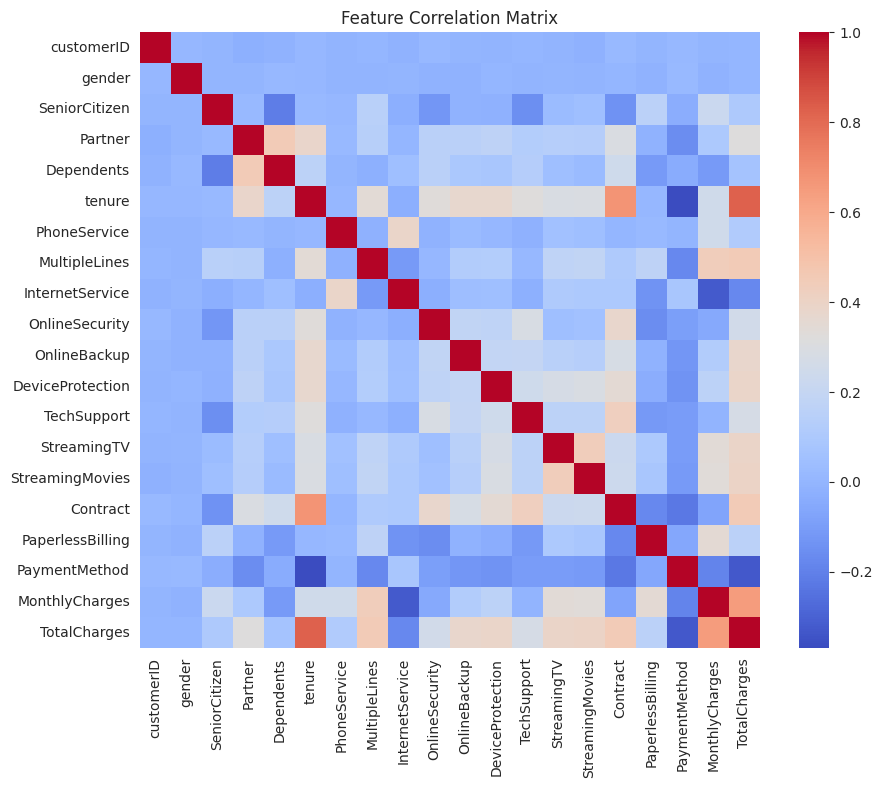

In [19]:
# Checking correlations

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(x.corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

Most features show weak correlation, suggesting churn depends on a combination of factors rather than a single dominant variable.

In [20]:
corr_matrix = x.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]

X = x.drop(columns=to_drop)

print("Dropped due to high correlation:", to_drop)

Dropped due to high correlation: []


In [21]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   int64  
 1   gender            7032 non-null   int64  
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   int64  
 4   Dependents        7032 non-null   int64  
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   int64  
 7   MultipleLines     7032 non-null   int64  
 8   InternetService   7032 non-null   int64  
 9   OnlineSecurity    7032 non-null   int64  
 10  OnlineBackup      7032 non-null   int64  
 11  DeviceProtection  7032 non-null   int64  
 12  TechSupport       7032 non-null   int64  
 13  StreamingTV       7032 non-null   int64  
 14  StreamingMovies   7032 non-null   int64  
 15  Contract          7032 non-null   int64  
 16  PaperlessBilling  7032 non-null   int64  
 17  

Feature Engineering (multi-collinearity)

In [22]:
vif_data = pd.DataFrame()

vif_data['Features'] = x.columns
vif_data

,Features
0,customerID
1,gender
2,SeniorCitizen
3,Partner
4,Dependents
5,tenure
6,PhoneService
7,MultipleLines
8,InternetService
9,OnlineSecurity


In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_val = []
for i in range(len(x.columns)):
  vif_val.append(variance_inflation_factor(x.values,i))

vif_data['vif_values'] = vif_val
vif_data

,Features,vif_values
0,customerID,3.702593
1,gender,1.961000
2,SeniorCitizen,1.370187
3,Partner,2.819912
4,Dependents,1.957881
5,tenure,15.570223
6,PhoneService,15.270514
7,MultipleLines,2.758529
8,InternetService,4.351030
9,OnlineSecurity,2.257669


In [24]:
x.drop('MonthlyCharges',axis=1,inplace=True)

In [25]:
vif_data = pd.DataFrame()

vif_data['Features'] = x.columns
vif_data

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_val = []
for i in range(len(x.columns)):
  vif_val.append(variance_inflation_factor(x.values,i))

vif_data['vif_values'] = vif_val
vif_data

,Features,vif_values
0,customerID,3.591056
1,gender,1.947396
2,SeniorCitizen,1.345094
3,Partner,2.814214
4,Dependents,1.957772
5,tenure,14.193213
6,PhoneService,8.839802
7,MultipleLines,2.527481
8,InternetService,3.659879
9,OnlineSecurity,2.256245


In [26]:
x.drop('tenure',axis=1,inplace=True)

In [27]:
vif_data = pd.DataFrame()

vif_data['Features'] = x.columns
vif_data

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_val = []
for i in range(len(x.columns)):
  vif_val.append(variance_inflation_factor(x.values,i))

vif_data['vif_values'] = vif_val
vif_data

,Features,vif_values
0,customerID,3.527566
1,gender,1.933780
2,SeniorCitizen,1.343650
3,Partner,2.750239
4,Dependents,1.956522
5,PhoneService,8.817577
6,MultipleLines,2.518684
7,InternetService,3.495487
8,OnlineSecurity,2.240953
9,OnlineBackup,2.448119


In [28]:
x.drop('PhoneService',axis=1,inplace=True)

In [29]:
vif_data = pd.DataFrame()

vif_data['Features'] = x.columns
vif_data

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_val = []
for i in range(len(x.columns)):
  vif_val.append(variance_inflation_factor(x.values,i))

vif_data['vif_values'] = vif_val
vif_data

,Features,vif_values
0,customerID,3.280750
1,gender,1.895534
2,SeniorCitizen,1.340985
3,Partner,2.742035
4,Dependents,1.951370
5,MultipleLines,2.516553
6,InternetService,2.570221
7,OnlineSecurity,2.220158
8,OnlineBackup,2.446358
9,DeviceProtection,2.621328


In [30]:
x.drop('TotalCharges',axis=1,inplace=True)

In [31]:
vif_data = pd.DataFrame()

vif_data['Features'] = x.columns
vif_data

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_val = []
for i in range(len(x.columns)):
  vif_val.append(variance_inflation_factor(x.values,i))

vif_data['vif_values'] = vif_val
vif_data

,Features,vif_values
0,customerID,3.280539
1,gender,1.895210
2,SeniorCitizen,1.329071
3,Partner,2.664916
4,Dependents,1.936139
5,MultipleLines,2.197928
6,InternetService,2.370124
7,OnlineSecurity,2.182331
8,OnlineBackup,2.285244
9,DeviceProtection,2.542503


In [32]:
x.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [33]:
x.shape

(7032, 16)

In [34]:
churn_pro = x.copy()
churn_pro['Churn'] = y
churn_pro.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,5365,0,0,1,0,1,0,0,2,0,0,0,0,0,1,2,0
1,3953,1,0,0,0,0,0,2,0,2,0,0,0,1,0,3,0
2,2558,1,0,0,0,0,0,2,2,0,0,0,0,0,1,3,1
3,5524,1,0,0,0,1,0,2,0,2,2,0,0,1,0,0,0
4,6500,0,0,0,0,0,1,0,0,0,0,0,0,0,1,2,1


In [35]:
# Downloading csv data for Regression model

churn_pro.to_csv('processed_churn.csv',index=False)

from google.colab import files
files.download("processed_churn.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>